# Generalized GNN-EGG Benchmark Notebook

This notebook demonstrates how to run the reusable pipeline in ``new_src`` to train and evaluate a GNN-EGG model on any dataset available through PyTorch Geometric's benchmark loaders. Provide a dataset name such as `"MUTAG"`, `"PROTEINS"`, or any Planetoid task and re-run the notebook to reproduce the end-to-end workflow.


## 1. Environment setup


In [1]:
import sys
sys.path.append("../..")

import random
from pathlib import Path
import importlib

import numpy as np
import torch

# Reproducibility controls. Adjust the seed if you need multiple runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

import new_src
from new_src.config import (
    DatasetConfig,
    ExplaineeConfig,
    GeneratorConfig,
    ExperimentConfig,
    LossTermConfig,
)
from new_src.workflow import GNNEggExperiment
from new_src.data import make_loaders

importlib.reload(new_src)

<module 'new_src' from '/repo/results/Generic/../../new_src/__init__.py'>

## 2. Configure the dataset and model

Edit the parameters in the next cell to target a specific benchmark dataset or to customize the explainee and generator hyper-parameters. The configuration objects map directly onto the classes defined in ``new_src.config``.


In [2]:
# Dataset + experiment configuration
DATASET_NAME = "MUTAG"  # Any dataset supported by TUDataset/Planetoid/GNNBenchmarkDataset
TARGET_CLASS = 1            # Integer label the generator should target
DATA_ROOT = Path("data") / DATASET_NAME

dataset_cfg = DatasetConfig(
    name=DATASET_NAME,
    root=str(DATA_ROOT),
    train_ratio=0.8,
    val_ratio=0.1,
    stratified=True,
    seed=SEED,
)

explainee_cfg = ExplaineeConfig(
    hidden_channels=64,
    num_layers=3,
    dropout=0.1,
    lr=1e-3,
    weight_decay=0.0,
    epochs=50,
    batch_size=64,
)

generator_cfg = GeneratorConfig(
    max_node_size=None,  # Defaults to the largest training graph
    cont_node_feats=None,
    dis_node_feats=None,
    cont_edge_feats=None,
    dis_edge_feats=None,
    temp=1.0,
    batch_size=4,
    allow_self_loops=True,
    loss_weights=torch.tensor([1.0, 1.0, 1.0, 1.0]),
)

# Register any additional pairwise loss terms here. Each callable should accept
# (generated_batch, observed_batch) arguments and return a scalar tensor.
extra_losses = []  # e.g., [LossTermConfig(name="mmd", weight=0.5, fn=my_loss_fn)]

experiment_cfg = ExperimentConfig(
    dataset=dataset_cfg,
    explainee=explainee_cfg,
    generator=generator_cfg,
    target_class=TARGET_CLASS,
    extra_loss_terms=extra_losses,
)


## 3. Prepare data, train the explainee, and build the generator

Running the experiment orchestrates dataset loading, splitting, explainee training, and generator construction. The returned artifacts bundle everything needed for subsequent analysis.


In [3]:
experiment = GNNEggExperiment(experiment_cfg)
artifacts = experiment.run()

splits = artifacts.dataset_splits
print(f'Train graphs: {len(splits.train)}')
print(f'Validation graphs: {len(splits.val)}')
print(f'Test graphs: {len(splits.test)}')

print()
print('Explainee training history:')
for key, values in artifacts.history.items():
    if not values:
        continue
    print(f'  {key}: start={values[0]:.4f} -> end={values[-1]:.4f}')


Train graphs: 150
Validation graphs: 18
Test graphs: 20

Explainee training history:
  train_loss: start=0.9783 -> end=0.4188
  val_loss: start=0.6527 -> end=0.2767
  val_acc: start=0.8889 -> end=0.8889


/repo/results/Generic/../../egg_models/base_trainer.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(init_scale=3_000)


### Explainee evaluation

Assess the trained surrogate on the held-out splits. Some datasets may not provide a validation or test partition after splitting; in that case the corresponding metric is skipped.


In [4]:
from typing import Dict, Optional

criterion = torch.nn.CrossEntropyLoss()
device = experiment.device
explainee = artifacts.explainee.to(device)
train_loader, val_loader, test_loader = make_loaders(
    splits, batch_size=experiment_cfg.explainee.batch_size, shuffle_train=False
)

def evaluate_loader(name: str, loader) -> Optional[Dict[str, float]]:
    dataset_size = len(loader.dataset) if hasattr(loader, 'dataset') else 0
    if dataset_size == 0:
        print(f'{name.title()} split is empty; skipping evaluation.')
        return None
    total_loss = 0.0
    correct = 0
    total = 0
    explainee.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = explainee(batch)
            loss = criterion(logits, batch.y.view(-1))
            total_loss += loss.item() * batch.num_graphs
            preds = logits.argmax(dim=-1)
            correct += (preds == batch.y.view(-1)).sum().item()
            total += batch.num_graphs
    if total == 0:
        print(f'{name.title()} split produced no graphs; skipping evaluation.')
        return None
    metrics = {
        'loss': total_loss / total,
        'accuracy': correct / total,
    }
    print(f"{name.title()} metrics: loss={metrics['loss']:.4f}, accuracy={metrics['accuracy']:.4f}")
    return metrics

eval_results = {
    'train': evaluate_loader('train', train_loader),
    'val': evaluate_loader('validation', val_loader),
    'test': evaluate_loader('test', test_loader),
}


Train metrics: loss=0.3894, accuracy=0.8267
Validation metrics: loss=0.2767, accuracy=0.8889
Test metrics: loss=0.5822, accuracy=0.7000


## 4. Train the generator

The ``GenericGNNEggTrainer`` attached to the artifacts exposes ``train_one_epoch`` for fine-grained control and logs the constituent loss terms. Adjust ``GENERATOR_EPOCHS`` to trade off runtime for quality.


In [5]:
GENERATOR_EPOCHS = 50

generator_logs = []
for epoch in range(GENERATOR_EPOCHS):
    metrics = artifacts.trainer.train_one_epoch()
    metrics['epoch'] = epoch + 1
    generator_logs.append(metrics)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        summary = ', '.join(
            f"{key}={value:.4f}"
            for key, value in metrics.items()
            if isinstance(value, (float, int))
        )
        print(f'Epoch {epoch + 1}: {summary}')


{'cont_node_feats': tensor([[[-2.2347e-01,  6.4615e-01,  3.4884e-01, -2.4069e-01,  1.1478e+00,
           1.5925e-01,  8.4305e-01],
         [-7.7042e-01, -9.2532e-01, -6.3382e-01,  1.3770e-01, -1.0841e-01,
           3.0732e-01,  4.5116e-01],
         [-8.4920e-02,  6.7832e-01, -2.2147e-01,  8.4169e-01,  1.0936e-01,
          -1.2833e+00, -3.8532e-01],
         [-5.0873e-01, -1.0070e+00, -7.3624e-01, -2.2145e-01,  2.5147e-01,
           8.8533e-01, -3.4412e-01],
         [ 4.9271e-01,  8.3946e-01,  8.4086e-01,  2.5859e-01, -2.8649e-02,
          -3.8446e-01, -4.5622e-01],
         [ 3.2571e-01, -4.9841e-02, -1.0320e+00,  2.0629e-01, -5.9198e-01,
          -5.3901e-01, -1.0685e+00],
         [ 2.4907e-01, -1.3823e+00,  4.9325e-01, -6.0582e-01, -9.4250e-01,
          -1.8280e-01, -6.8807e-01],
         [-4.4788e-01,  4.6281e-02,  2.5184e-02, -6.3772e-01,  5.4846e-01,
           4.8810e-01,  7.0254e-01],
         [ 8.9472e-01,  2.6245e-01,  7.3399e-01, -3.7830e-01,  3.3429e-01,
         

AttributeError: 'NoneType' object has no attribute 'unbind'

### Inspect generator predictions

Sample multiple graphs from the trained generator and score them with the explainee. The mean probability for the target class provides a quick proxy for generation quality.


In [ ]:
def sample_generator_predictions(num_samples: int = 64):
    generator = artifacts.generator
    generator.eval()
    explainee.eval()
    scores = []
    with torch.no_grad():
        for _ in range(num_samples):
            generated = generator()
            batch = artifacts.trainer.egg_to_ex(generated)
            batch = batch.to(device)
            logits = explainee(batch)
            probs = torch.softmax(logits, dim=-1).mean(dim=0)
            scores.append(probs[experiment_cfg.target_class].item())
    generator.train()
    explainee.train()
    return scores

predictions = sample_generator_predictions(num_samples=128)
print(f'Mean target probability: {np.mean(predictions):.4f}')
print(f'Standard deviation: {np.std(predictions):.4f}')


Mean target probability: 0.4162
Standard deviation: 0.1327


### Optional: visualize a sampled graph

The following cell attempts to draw one of the generated graphs. Install ``networkx`` and ``matplotlib`` if they are not already available.


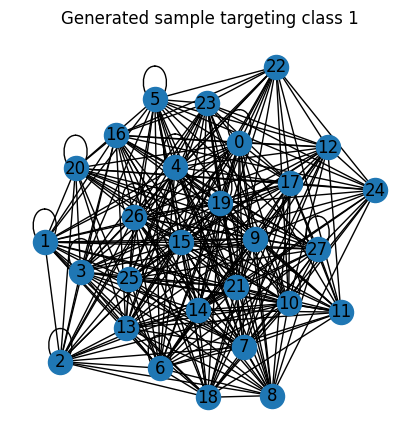

In [ ]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    from torch_geometric.utils import to_networkx

    generated = artifacts.generator()
    batch = artifacts.trainer.egg_to_ex(generated)
    data = batch.to_data_list()[0]
    G = to_networkx(data, to_undirected=True)
    plt.figure(figsize=(4, 4))
    nx.draw(G, with_labels=True, node_color='tab:blue')
    plt.title(f'Generated sample targeting class {experiment_cfg.target_class}')
    plt.show()
except ImportError:
    print('Install networkx and matplotlib to enable visualization.')


## 5. Next steps

- Adjust the explainee configuration to mirror architectures from prior experiments.
- Add custom distance-based losses through ``LossTermConfig`` for domain-specific constraints.
- Extend the sampling utilities to export generated graphs for downstream analysis.
